FIRST 5 ROWS
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

MISSING VALUES
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

CLEANED DATASET SAVED

PROCESSED DATA SAVED


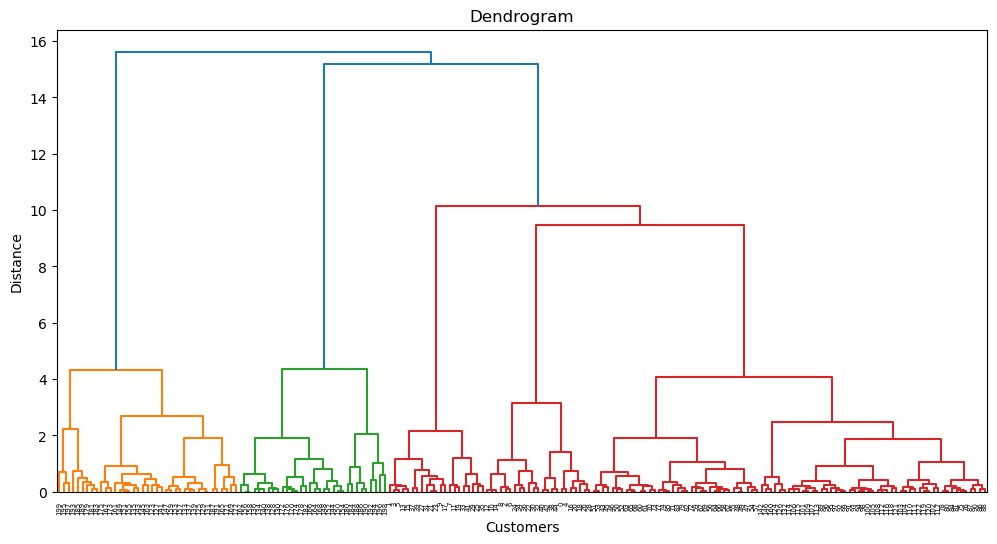


CLUSTERED DATA
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  

CLUSTERED DATA SAVED


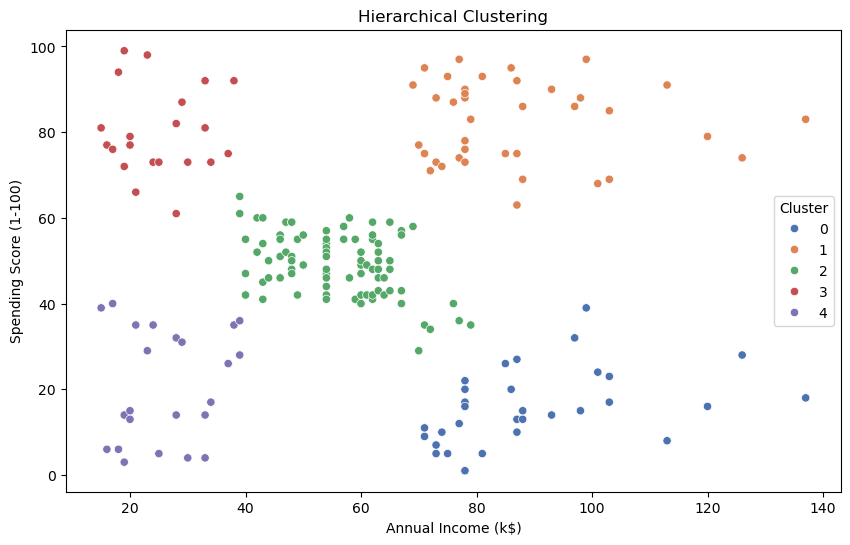

In [1]:
# ==========================================
# HIERARCHICAL CLUSTERING
# CUSTOMER SEGMENTATION
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import os
import warnings

warnings.filterwarnings("ignore")

os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs(
    "../../../datasets/cleaned/hierarchical",
    exist_ok=True
)

os.makedirs(
    "../../../datasets/processed/hierarchical",
    exist_ok=True
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv(
    "../../../datasets/raw/mall_customers/Mall_Customers.csv"
)

print("FIRST 5 ROWS")
print(df.head())

# ==========================================
# 2. CLEANING
# ==========================================

df = df.drop_duplicates()

df = df.dropna()

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================
# 3. SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "../../../datasets/cleaned/hierarchical/cleaned_mall.csv",
    index=False
)

print("\nCLEANED DATASET SAVED")

# ==========================================
# 4. FEATURE SELECTION
# ==========================================

X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# ==========================================
# 5. FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# 6. SAVE PROCESSED DATASET
# ==========================================

pd.DataFrame(X_scaled).to_csv(
    "../../../datasets/processed/hierarchical/X_scaled.csv",
    index=False
)

print("\nPROCESSED DATA SAVED")

# ==========================================
# 7. DENDROGRAM
# ==========================================

linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title("Dendrogram")

plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

# ==========================================
# 8. CREATE MODEL
# ==========================================

model = AgglomerativeClustering(
    n_clusters=5
)

# ==========================================
# 9. FIT MODEL
# ==========================================

clusters = model.fit_predict(
    X_scaled
)

# ==========================================
# 10. ADD CLUSTERS
# ==========================================

df["Cluster"] = clusters

print("\nCLUSTERED DATA")
print(df.head())

# ==========================================
# 11. SAVE CLUSTER RESULTS
# ==========================================

df.to_csv(
    "../../../datasets/processed/hierarchical/clustered_data.csv",
    index=False
)

print("\nCLUSTERED DATA SAVED")

# ==========================================
# 12. VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="deep"
)

plt.title("Hierarchical Clustering")

plt.show()

# ==========================================
# END
# ==========================================